In [2]:
import numpy as np
import matplotlib.pyplot as plt
from Exp_Poly_Solver import SphericalExpRKSolver

## Testing time step size:

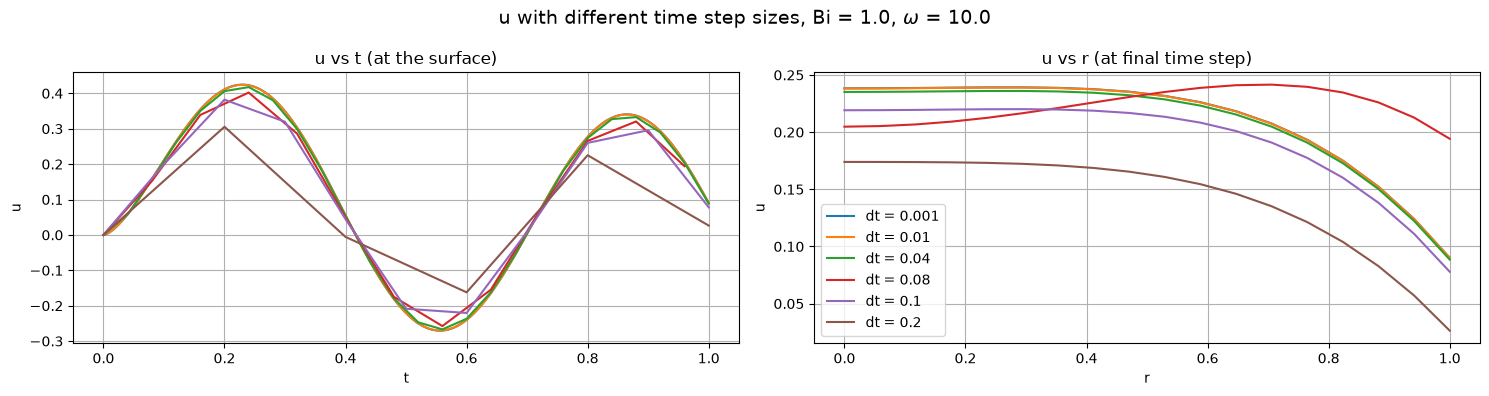

In [14]:
N= 18
Bi = 1.0
omega = 10.0
dt_values = [1e-3, 0.01, 0.04, 0.08, 0.1, 0.2]
t_end = 1.0

fig, axes = plt.subplots(1, 2, figsize=(15, 4), sharex=True)
ax = axes[0]
for k, dt in enumerate(dt_values):
    solver = SphericalExpRKSolver(N, dt, Bi, omega, t_end)
    times, r, U = solver.solve()
    ax.plot(times, U[:, -1], label = fr"dt = {dt}")
    ax.set_xlabel("t")
    ax.set_ylabel("u")
    ax.set_title("u vs t (at the surface)")
    ax.grid(True)

ax = axes[1]
for k, dt in enumerate(dt_values):
    solver = SphericalExpRKSolver(N, dt, Bi, omega, t_end)
    times, r, U = solver.solve()
    ax.plot(r, U[-1, :], label = fr"dt = {dt}")
    ax.set_xlabel("r")
    ax.set_ylabel("u")
    ax.set_title("u vs r (at final time step)")
    ax.grid(True)


fig.suptitle(
    fr"u with different time step sizes, Bi = {Bi}, $\omega$ = {omega}",
    fontsize=14
)
plt.legend()
plt.tight_layout()
plt.show()


# fig, axes = plt.subplots(2, 3, figsize=(15, 6), sharex=True)
# axes = axes.ravel()
# for k, dt in enumerate(dt_values):
#     ax = axes[k]
#     solver = SphericalExpRKSolver(N, dt, Bi, omega, t_end)
#     times, r, U = solver.solve()

#     ax.plot(times, U[:, -1])
#     ax.set_title(fr"dt = {dt}")
#     ax.set_xlabel("t")
#     ax.set_ylabel("u")
#     ax.grid(True)

# fig.suptitle(
#     fr"u at the surface as a function of time, Bi = {Bi}, $\omega^* = {omega}$",
#     fontsize=14
# )
# plt.legend()
# plt.tight_layout()
# plt.show()

The exponential Runge--Kutta method remains stable even for time steps for which explicit Euler becomes unstable, because the stiff linear diffusion part is integrated by the matrix exponential.
However, large $\Delta t$ can still be inaccurate

### Temperature change in time

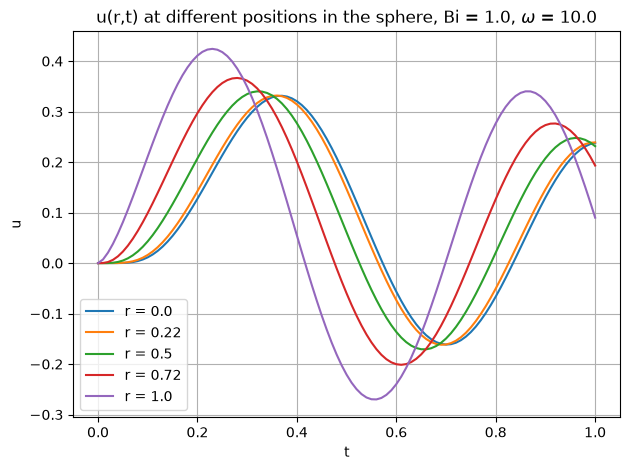

In [6]:
N = 18
Bi = 1.0
omega = 10.0
dt = 0.01
t_end = 1.0

r_dict= {0:0.0, 4:0.22, 9:0.5, 13:0.72, -1:1.0}

for r_idx, r_value in r_dict.items():
    solver = SphericalExpRKSolver(N, dt, Bi, omega, t_end=t_end)
    times, r, U = solver.solve()

    plt.plot(times, U[:, r_idx], label= fr"r = {r_value}")
    
plt.xlabel("t")
plt.ylabel("u")
plt.grid(True)
plt.legend()
plt.title(fr"u(r,t) at different positions in the sphere, Bi = {Bi}, $\omega$ = {omega}")
plt.tight_layout()
plt.show()

phase delay toewards the center

## $\omega$

In [17]:
from Theta_Solver import SphericalHeatCondSolver

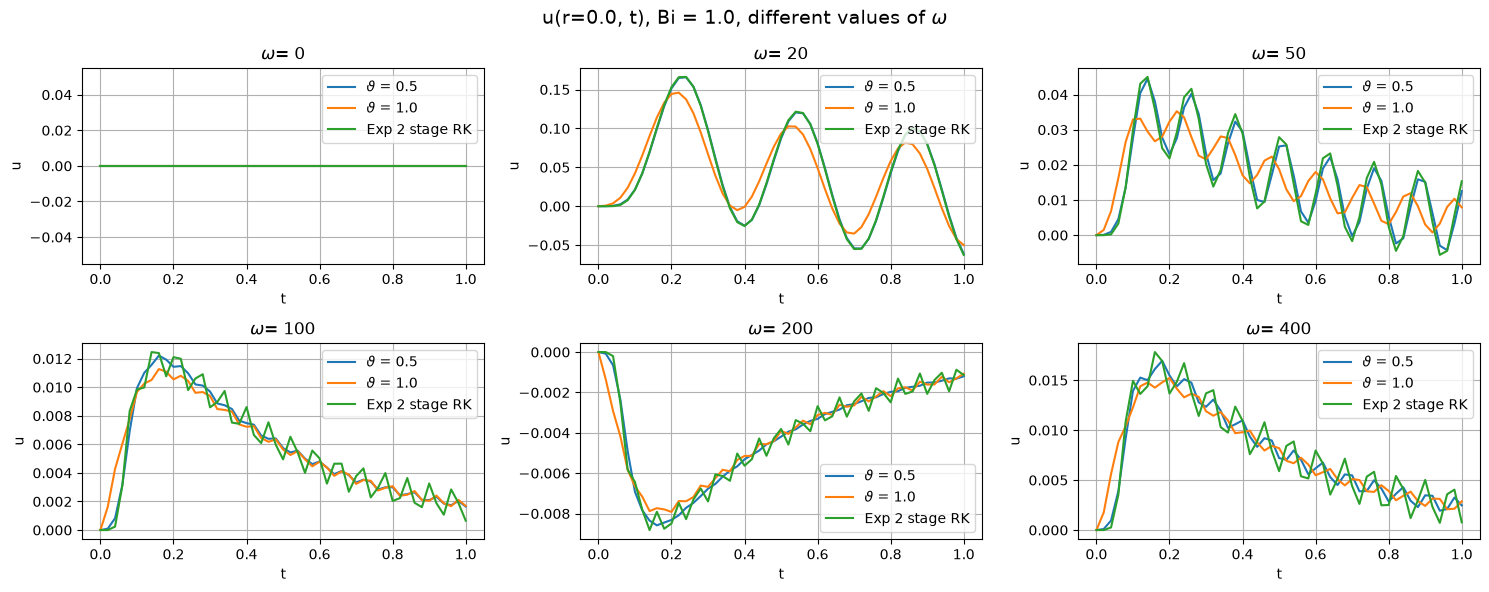

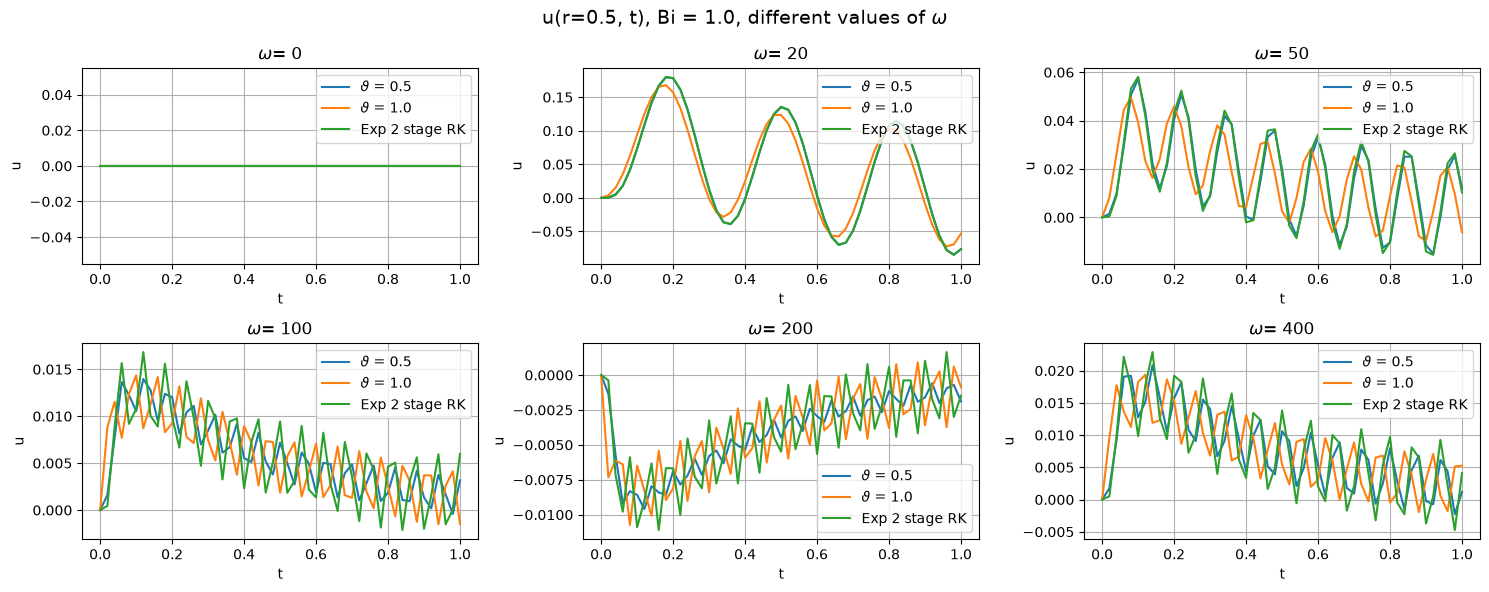

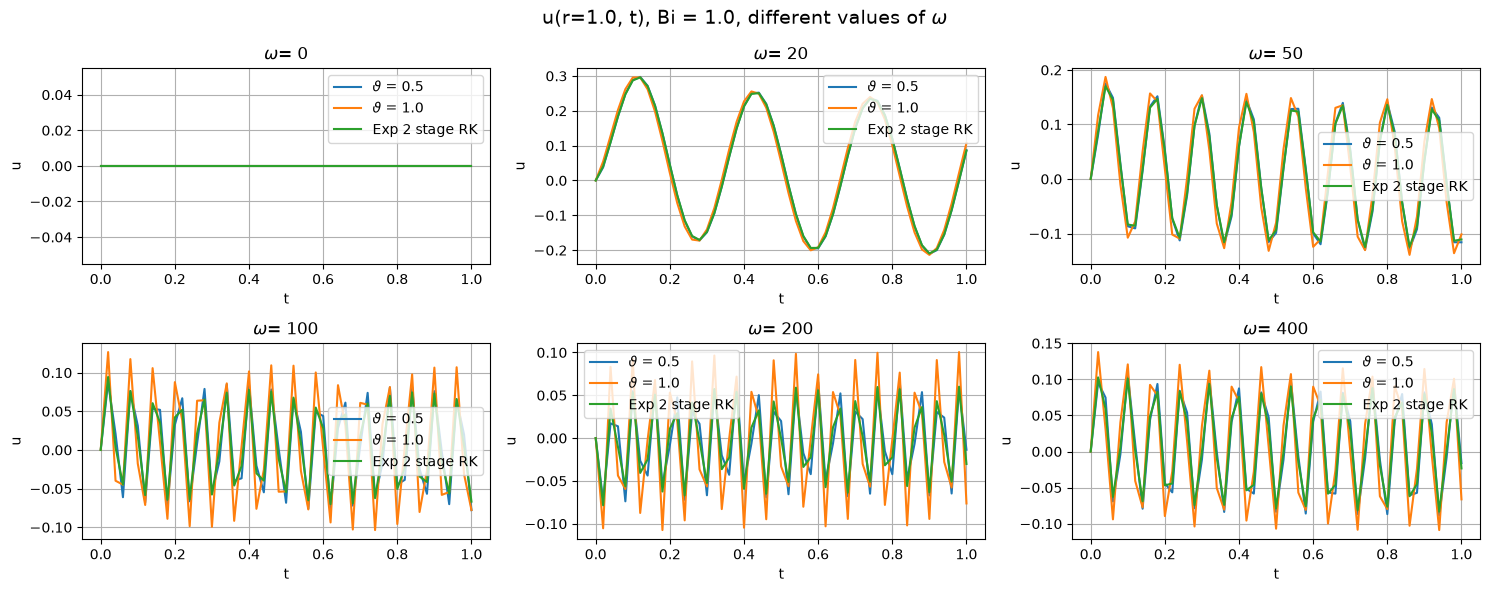

In [23]:
N = 18
Bi = 1.0
dt = 0.02
t_end = 1.0

n_timesteps = int(t_end / dt)

omega_values = [0, 20, 50, 100, 200, 400]
theta_values = [0.0, 0.5, 1.0]
stable_theta_values = [0.5, 1.0]
r_dict = {0:0.0, 9:0.5, -1:1.0}

for r_idx, r_value in r_dict.items():
    fig, axes = plt.subplots(2, 3, figsize=(15, 6))
    axes = axes.ravel()

    
    for k, omega in enumerate(omega_values):
        ax = axes[k]
        for theta in stable_theta_values:
            solver = SphericalHeatCondSolver(N, dt, Bi, omega, theta= theta, t_end=t_end)
            times, r, U = solver.solve()
            
            solver2 = SphericalExpRKSolver(N, dt, Bi, omega, t_end=t_end)
            times2, r2, U2 = solver2.solve()
            ax.plot(times, U[:, r_idx], label= fr"$\vartheta$ = {theta}")
        ax.plot(times2, U2[:, r_idx], label = "Exp 2 stage RK")
        ax.set_title(fr"$\omega$= {omega}")
        #ax.set_title(f"$u(r,t)$")
        ax.set_xlabel("t")
        ax.set_ylabel("u")
        ax.grid(True)
        ax.legend()

    fig.suptitle(
        fr"u(r={r_value}, t), Bi = {Bi}, different values of $\omega$",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

- more similar to trapezoidal
- near the boundary reflects the external bound oscillations a lot, even at high oscillations. the methods look very similar even at high time step size.
- internally more mismatch, especially at high oscillations making it difficult to model precisely the temperature inside
- at the origin still oscillating behavior in time, but delayed wrt to the surface, and at high frequency thethree methods do not agree.

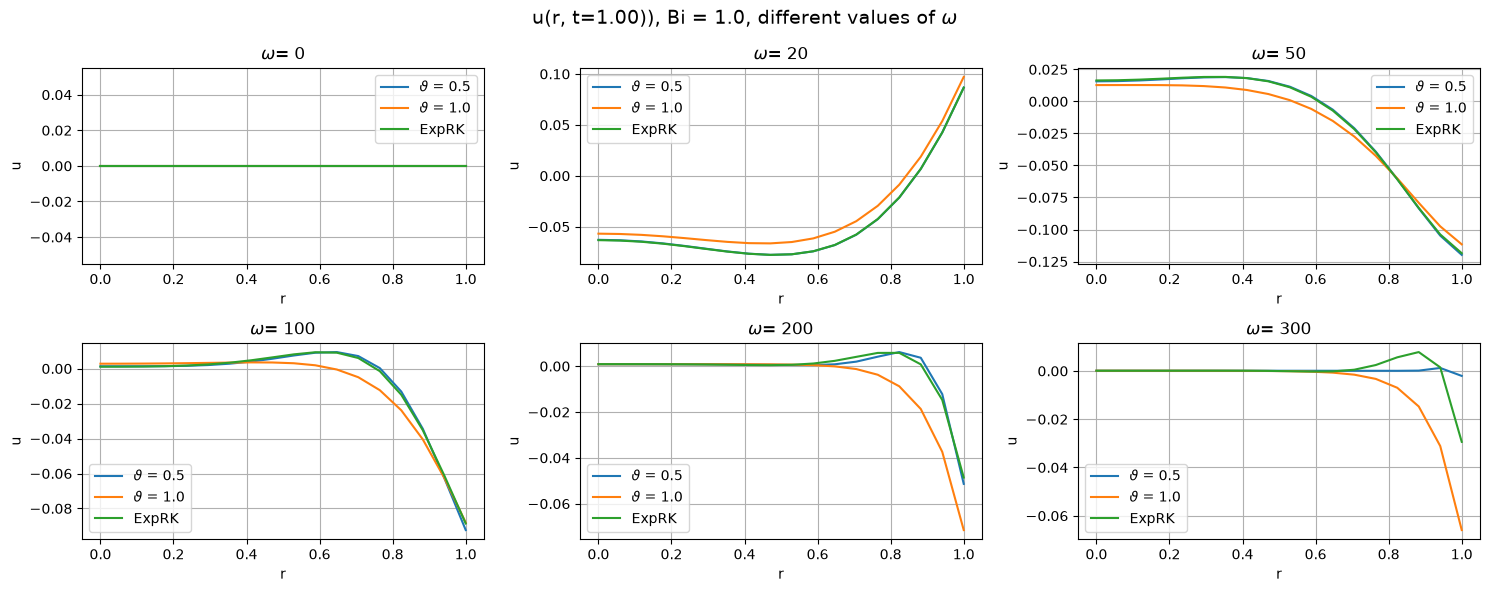

In [24]:
N = 18
Bi = 1.0
dt = 0.01
t_end = 1.0

n_timesteps = int(t_end / dt)

omega_values = [0, 20, 50, 100, 200, 300]
theta_values = [0.0, 0.5, 1.0]
stable_theta_values = [0.5, 1.0]
t_steps = [20, 50, -1]


fig, axes = plt.subplots(2, 3, figsize=(15, 6))
axes = axes.ravel()


for k, omega in enumerate(omega_values):
    ax = axes[k]
    for theta in stable_theta_values:
        solver = SphericalHeatCondSolver(N, dt, Bi, omega, theta= theta, t_end=t_end)
        times, r, U = solver.solve()
        ax.plot(r, U[-1, :], label= fr"$\vartheta$ = {theta}")
        
    solver2 = SphericalExpRKSolver(N, dt, Bi, omega, t_end=t_end)
    times2, r2, U2 = solver2.solve()
    ax.plot(r2, U2[-1, :], label = "ExpRK")

    ax.set_title(fr"$\omega$= {omega}")
    #ax.set_title(f"$u(r,t)$")
    ax.set_xlabel("r")
    ax.set_ylabel("u")
    ax.grid(True)
    ax.legend()

fig.suptitle(
    fr"u(r, t={times[-1]:.2f})), Bi = {Bi}, different values of $\omega$",
    fontsize=14
)

plt.tight_layout()
plt.show()

- stronger oscillations near the surface
- smaller change in temperature near the center
- weaker penetration especially for large $\omega$

## Bi

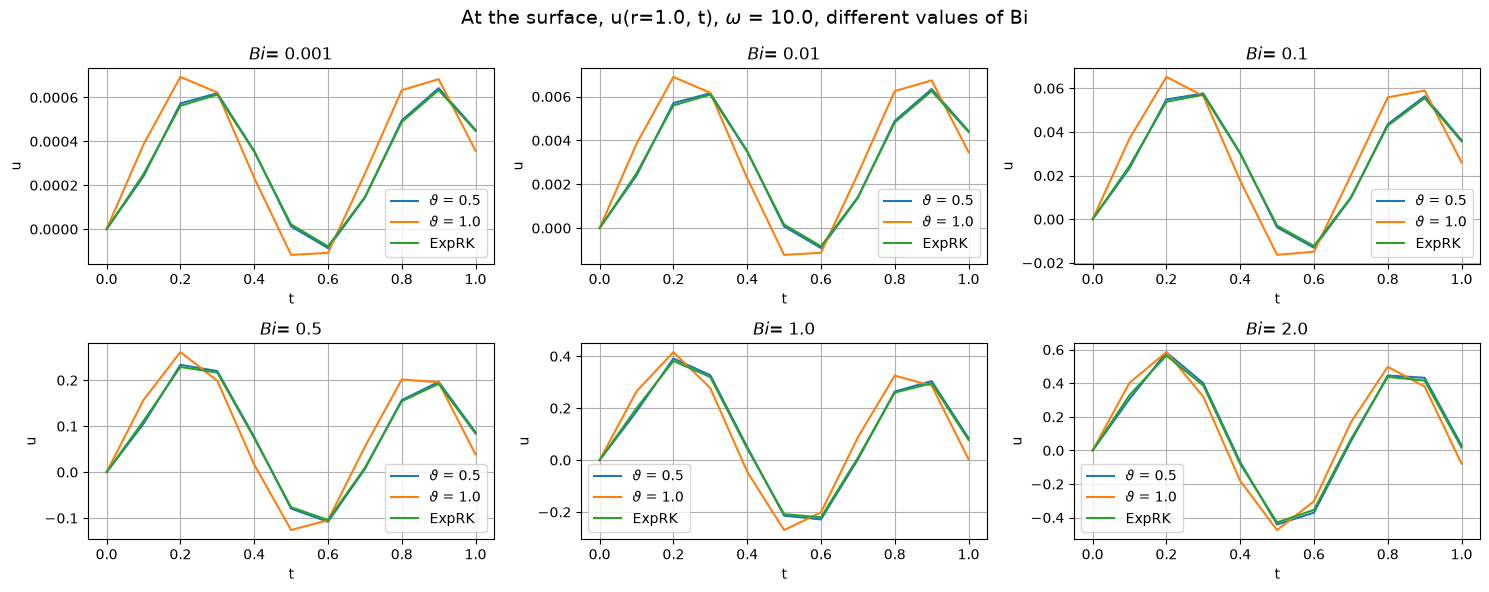

In [28]:
N = 18
omega = 10.0
dt = 0.1
t_end = 1.0

n_timesteps = int(t_end / dt)

Bi_values = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0]
theta_values = [0.5, 1.0]


fig, axes = plt.subplots(2, 3, figsize=(15, 6))
axes = axes.ravel()


for k, Bi in enumerate(Bi_values):
    ax = axes[k]
    for theta in theta_values:
        solver = SphericalHeatCondSolver(N, dt, Bi, omega, theta= theta, t_end=t_end)
        times, r, U = solver.solve()
        ax.plot(times, U[:, -1], label= fr"$\vartheta$ = {theta}")

    solver2 = SphericalExpRKSolver(N, dt, Bi, omega, t_end=t_end)
    times2, r2, U2 = solver2.solve()
    ax.plot(times2, U2[:, -1], label = "ExpRK")

    ax.set_title(fr"$Bi$= {Bi}")
    #ax.set_title(f"$u(r,t)$")
    ax.set_xlabel("t")
    ax.set_ylabel("u")
    ax.grid(True)
    ax.legend()

fig.suptitle(
    fr"At the surface, u(r=1.0, t), $\omega$ = {omega}, different values of Bi",
    fontsize=14
)

plt.tight_layout()
plt.show()

Very similar to trapezoidal again

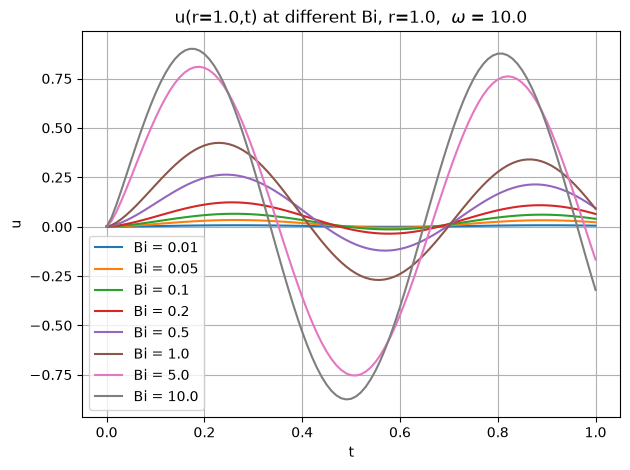

In [29]:
N = 18
omega = 10.0
dt = 0.01
t_end = 1.0

n_timesteps = int(t_end / dt)

Bi_values = [0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 5.0, 10.0]
for Bi_idx, Bi in enumerate(Bi_values):
    solver = SphericalExpRKSolver(N, dt, Bi, omega, t_end=t_end)
    times, r, U = solver.solve()

    plt.plot(times, U[:, -1], label= fr"Bi = {Bi}")
    
plt.xlabel("t")
plt.ylabel("u")
plt.grid(True)
plt.legend()
plt.title(fr"u(r=1.0,t) at different Bi, r=1.0,  $\omega$ = {omega}")
plt.tight_layout()
plt.show()

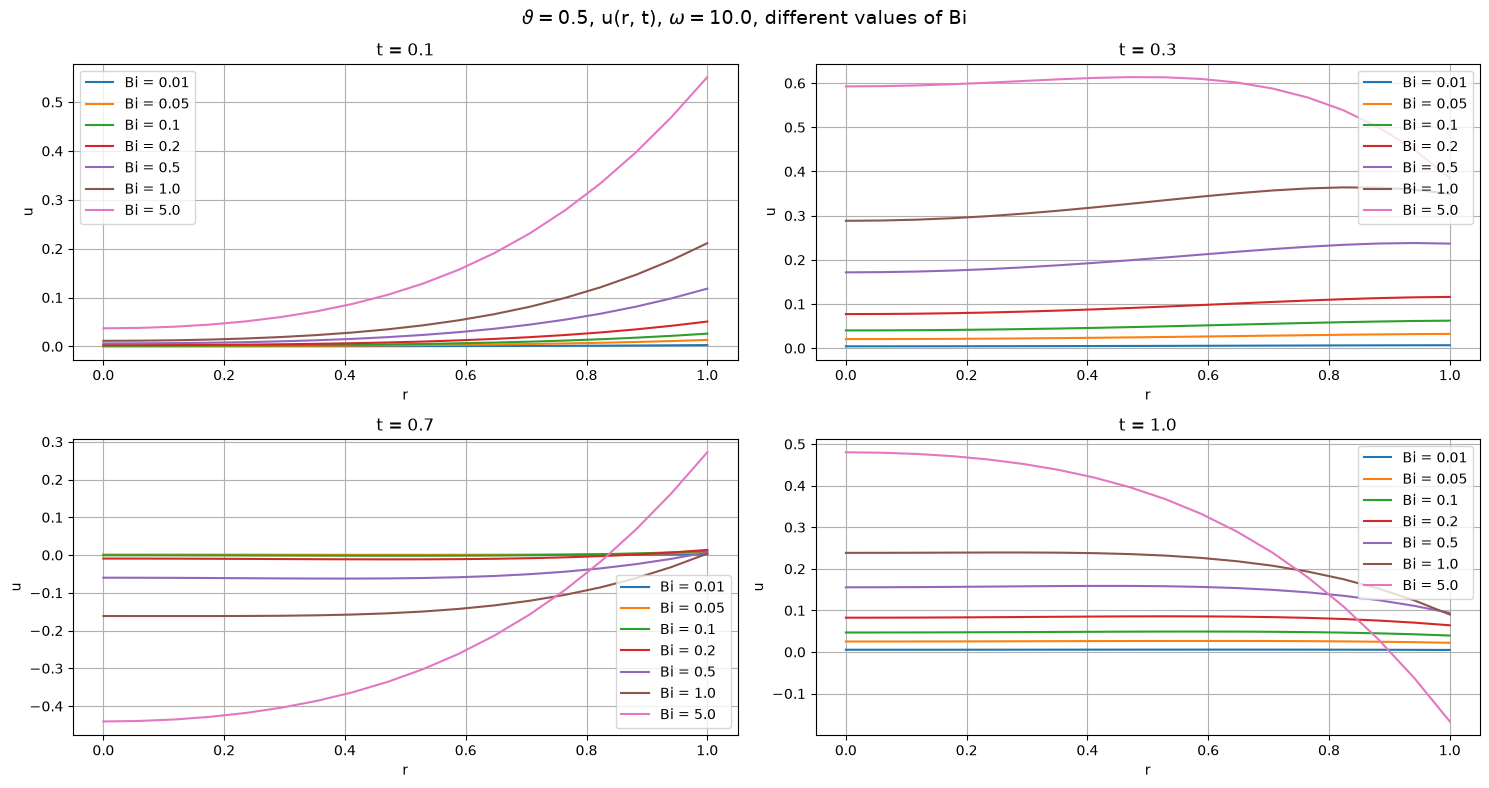

In [30]:
N = 18
omega = 10.0
dt = 0.001
t_end = 1.0

n_timesteps = int(t_end / dt)

Bi_values = [0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 5.0]
t_values = [0.1, 0.3, 0.7, 1.0]

fig, axes = plt.subplots(2, 2, figsize=(15, 8))
axes = axes.ravel()

for k, t_val in enumerate(t_values):
    ax = axes[k]
    for Bi in Bi_values:
        solver = SphericalExpRKSolver(N, dt, Bi, omega, t_end=t_end)
        times, r, U = solver.solve()
        idx = np.argmin(np.abs(times - t_val))
        ax.plot(r, U[idx, :], label= fr"Bi = {Bi}")
        ax.set_xlabel("r")
        ax.set_ylabel("u")
        ax.set_title(fr"t = {t_val}")
        ax.grid(True)
        ax.legend()
    

fig.suptitle(
    fr"$\vartheta=0.5$, u(r, t), $\omega= 10.0$, different values of Bi",
    fontsize=14
)
plt.tight_layout()
plt.show()

same behavior as in 1e.